#  Performance Analytics — Day 4
**Project:** Bluestock MF Analytics  
**Scope:** All 40 funds | Daily returns, CAGR, Sharpe, Sortino, Alpha, Beta, Max Drawdown, Scorecard  
**Benchmark:** Nifty 100 | Risk-Free Rate: 6.5% (RBI repo rate proxy)

---
## Contents
1. [Setup & Data Load](#1-setup)
2. [Daily Returns](#2-returns)
3. [CAGR Table (1yr / 3yr / 5yr)](#3-cagr)
4. [Sharpe Ratio Ranking](#4-sharpe)
5. [Sortino Ratio Ranking](#5-sortino)
6. [Alpha & Beta (OLS vs Nifty 100)](#6-alpha-beta)
7. [Maximum Drawdown](#7-drawdown)
8. [Fund Scorecard (0–100)](#8-scorecard)
9. [Benchmark Comparison Chart](#9-benchmark)


## 1. Setup & Data Load <a id='1-setup'></a>

In [1]:
import warnings; warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from pathlib import Path

sns.set_theme(style="darkgrid", font_scale=1.05)

BASE  = Path().resolve().parent
PROC  = BASE / "data" / "processed"
CHARTS = BASE / "reports" / "charts"

RF_ANNUAL = 0.065        # RBI repo rate proxy
RF_DAILY  = RF_ANNUAL / 252

nav   = pd.read_csv(PROC / "02_nav_history_clean.csv",       parse_dates=["date"])
fund  = pd.read_csv(PROC / "01_fund_master_clean.csv",       parse_dates=["launch_date"])
bench = pd.read_csv(PROC / "10_benchmark_indices_clean.csv", parse_dates=["date"])

nav_wide   = nav.pivot(index="date", columns="amfi_code", values="nav").sort_index()
bench_wide = bench.pivot(index="date", columns="index_name", values="close_value").sort_index()
nifty50    = bench_wide["NIFTY50"].dropna()
nifty100   = bench_wide["NIFTY100"].dropna()

print(f"NAV matrix : {nav_wide.shape[0]} days x {nav_wide.shape[1]} funds")
print(f"Date range : {nav_wide.index.min().date()} to {nav_wide.index.max().date()}")


NAV matrix : 1608 days x 40 funds
Date range : 2022-01-03 to 2026-05-29


## 2. Daily Returns <a id='2-returns'></a>
`daily_return = NAV_t / NAV_t-1 - 1`

Expected: mean ~0%, std ~0.8–1.2%, no extreme spikes above ±10%.


Return distribution (all funds, all days):
  Mean : 0.0451%
  Std  : 0.8706%
  Min  : -5.810%
  Max  : 6.471%
  Days with abs return > 5% : 9


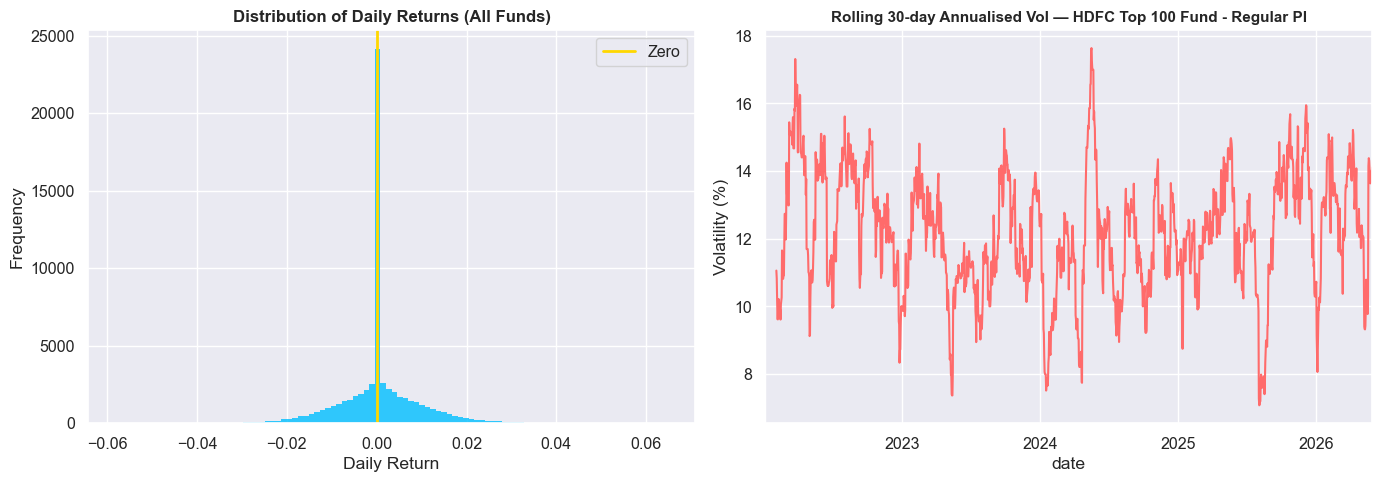

In [2]:
returns = nav_wide.pct_change().dropna(how="all")

desc = returns.stack().describe()
print("Return distribution (all funds, all days):")
print(f"  Mean : {desc['mean']*100:.4f}%")
print(f"  Std  : {desc['std']*100:.4f}%")
print(f"  Min  : {desc['min']*100:.3f}%")
print(f"  Max  : {desc['max']*100:.3f}%")
print(f"  Days with abs return > 5% : {(returns.abs() > 0.05).sum().sum()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
returns.stack().hist(ax=axes[0], bins=100, color="#00BFFF", edgecolor="none", alpha=0.8)
axes[0].set_title("Distribution of Daily Returns (All Funds)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Daily Return"); axes[0].set_ylabel("Frequency")
axes[0].axvline(0, color="gold", linewidth=2, label="Zero")
axes[0].legend()

# Rolling 30-day volatility for a sample fund
sample_code = nav_wide.columns[0]
sample_name = fund.loc[fund["amfi_code"]==sample_code,"scheme_name"].values[0][:30]
rolling_vol = returns[sample_code].rolling(30).std() * np.sqrt(252) * 100
rolling_vol.plot(ax=axes[1], color="#FF6B6B", linewidth=1.5)
axes[1].set_title(f"Rolling 30-day Annualised Vol — {sample_name}", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Volatility (%)")
plt.tight_layout(); plt.show()


## 3. CAGR Table <a id='3-cagr'></a>
`CAGR = (NAV_end / NAV_start) ^ (1/n) - 1`

n = number of years. Computed for 1yr, 3yr, 5yr lookback from the latest NAV date.


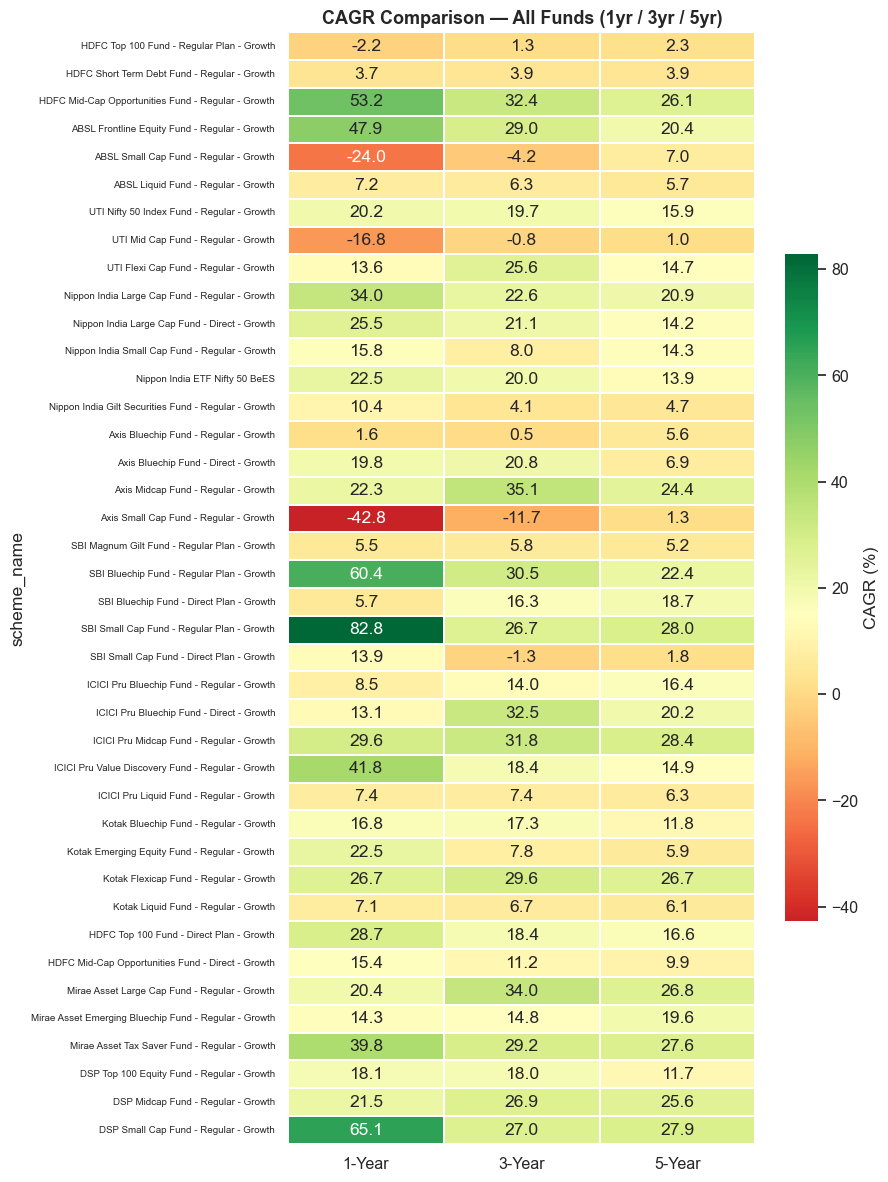


Top 10 by 3-Year CAGR:
                                       scheme_name    plan  cagr_1yr_pct  cagr_3yr_pct  cagr_5yr_pct
               Axis Midcap Fund - Regular - Growth Regular         22.26         35.11         24.45
     Mirae Asset Large Cap Fund - Regular - Growth Regular         20.36         34.00         26.80
         ICICI Pru Bluechip Fund - Direct - Growth  Direct         13.06         32.49         20.23
HDFC Mid-Cap Opportunities Fund - Regular - Growth Regular         53.23         32.44         26.07
          ICICI Pru Midcap Fund - Regular - Growth Regular         29.60         31.78         28.38
         SBI Bluechip Fund - Regular Plan - Growth Regular         60.44         30.46         22.38
            Kotak Flexicap Fund - Regular - Growth Regular         26.66         29.58         26.74
     Mirae Asset Tax Saver Fund - Regular - Growth Regular         39.75         29.18         27.63
     ABSL Frontline Equity Fund - Regular - Growth Regular         

In [3]:
def cagr(nav_series, years):
    end_date   = nav_series.dropna().index.max()
    start_date = end_date - pd.DateOffset(years=years)
    series     = nav_series.dropna()
    avail      = series.index
    start_idx  = avail.searchsorted(start_date)
    if start_idx >= len(avail): return np.nan
    nav_start  = series.iloc[start_idx]
    nav_end    = series.iloc[-1]
    if nav_start <= 0: return np.nan
    return (nav_end / nav_start) ** (1 / years) - 1

cagr_rows = []
for code_id in nav_wide.columns:
    s = nav_wide[code_id].dropna()
    row = {"amfi_code": code_id}
    for yr in [1, 3, 5]:
        row[f"cagr_{yr}yr_pct"] = round(cagr(s, yr) * 100, 2)
    cagr_rows.append(row)

cagr_df = (pd.DataFrame(cagr_rows)
           .merge(fund[["amfi_code","scheme_name","plan","sub_category","expense_ratio_pct"]],
                  on="amfi_code", how="left"))

# Heatmap of CAGR
pivot_cagr = cagr_df.set_index("scheme_name")[["cagr_1yr_pct","cagr_3yr_pct","cagr_5yr_pct"]]
fig, ax = plt.subplots(figsize=(9, 12))
sns.heatmap(pivot_cagr, annot=True, fmt=".1f", cmap="RdYlGn",
            center=15, ax=ax, linewidths=0.3,
            cbar_kws={"label": "CAGR (%)", "shrink": 0.6})
ax.set_title("CAGR Comparison — All Funds (1yr / 3yr / 5yr)", fontsize=13, fontweight="bold")
ax.set_xticklabels(["1-Year","3-Year","5-Year"], rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=7)
plt.tight_layout(); plt.show()

print("\nTop 10 by 3-Year CAGR:")
print(cagr_df[["scheme_name","plan","cagr_1yr_pct","cagr_3yr_pct","cagr_5yr_pct"]]
      .sort_values("cagr_3yr_pct", ascending=False).head(10).to_string(index=False))


## 4. Sharpe Ratio <a id='4-sharpe'></a>
`Sharpe = (Rp - Rf) / Std(Rp) × √252`

Rf = 6.5% annually (6.5/252 per day). A Sharpe > 1.0 is considered good.


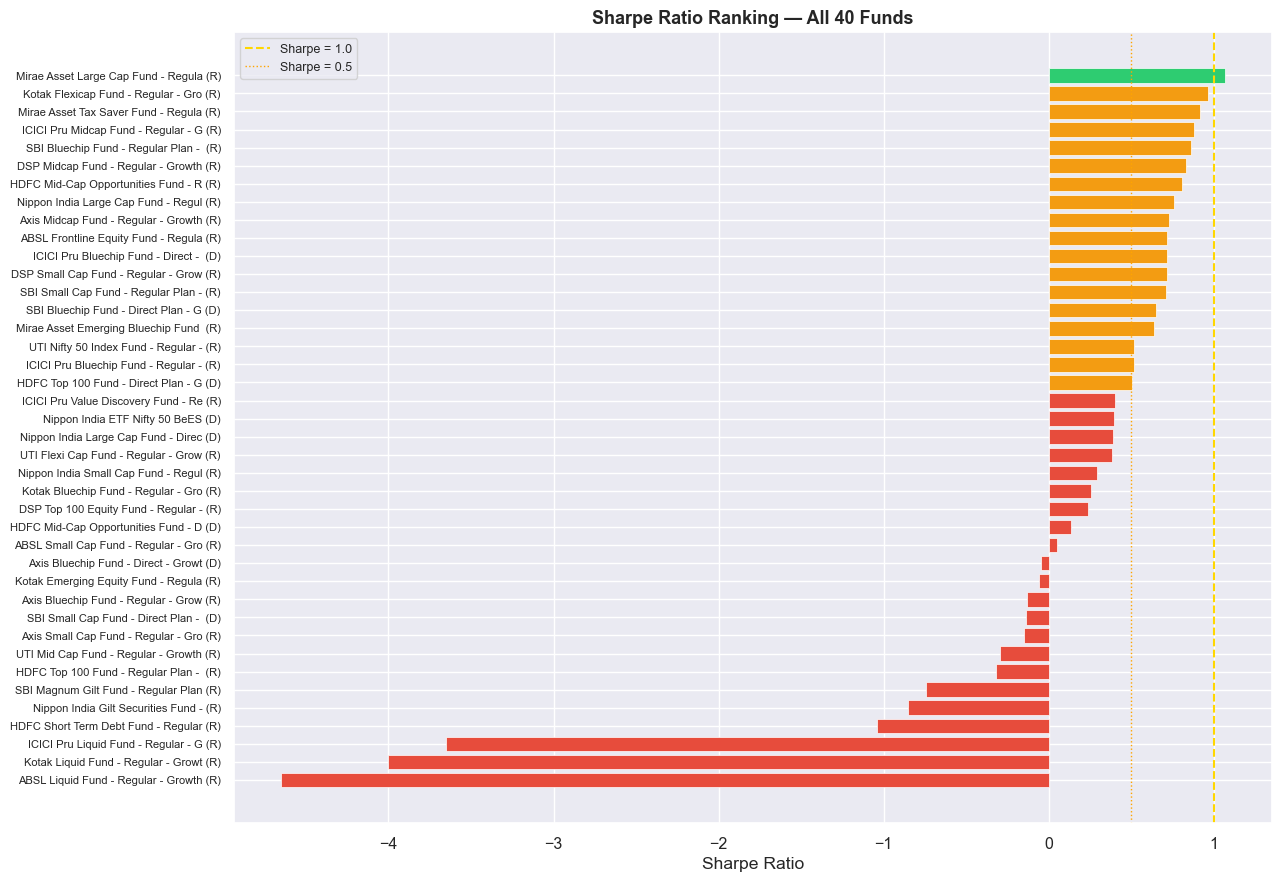

Funds with Sharpe > 1.0: 1
Funds with Sharpe > 0.5: 18


In [4]:
def sharpe(ret_series):
    excess = ret_series.dropna() - RF_DAILY
    if excess.std() == 0: return np.nan
    return (excess.mean() / excess.std()) * np.sqrt(252)

sharpe_scores = {c: sharpe(returns[c]) for c in returns.columns}
sharpe_df = (pd.Series(sharpe_scores, name="sharpe_ratio")
             .reset_index().rename(columns={"index":"amfi_code"})
             .merge(fund[["amfi_code","scheme_name","plan","sub_category"]], on="amfi_code", how="left")
             .sort_values("sharpe_ratio", ascending=False)
             .reset_index(drop=True))
sharpe_df.index += 1

fig, ax = plt.subplots(figsize=(13, 9))
colors = ["#2ecc71" if v >= 1.0 else "#f39c12" if v >= 0.5 else "#e74c3c"
          for v in sharpe_df["sharpe_ratio"]]
ax.barh(range(len(sharpe_df)), sharpe_df["sharpe_ratio"].values,
        color=colors, edgecolor="white", linewidth=0.5)
ax.set_yticks(range(len(sharpe_df)))
ax.set_yticklabels([f"{r['scheme_name'][:35]} ({r['plan'][0]})"
                    for _, r in sharpe_df.iterrows()], fontsize=8)
ax.invert_yaxis()
ax.axvline(1.0, color="gold", linestyle="--", linewidth=1.5, label="Sharpe = 1.0")
ax.axvline(0.5, color="orange", linestyle=":", linewidth=1, label="Sharpe = 0.5")
ax.set_xlabel("Sharpe Ratio"); ax.set_title("Sharpe Ratio Ranking — All 40 Funds", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
print(f"Funds with Sharpe > 1.0: {(sharpe_df['sharpe_ratio'] > 1.0).sum()}")
print(f"Funds with Sharpe > 0.5: {(sharpe_df['sharpe_ratio'] > 0.5).sum()}")


## 5. Sortino Ratio <a id='5-sortino'></a>
`Sortino = (Rp - Rf) / Downside_Std × √252`

Denominator uses only days where return < Rf. Penalises bad days only — better metric for skewed return distributions.


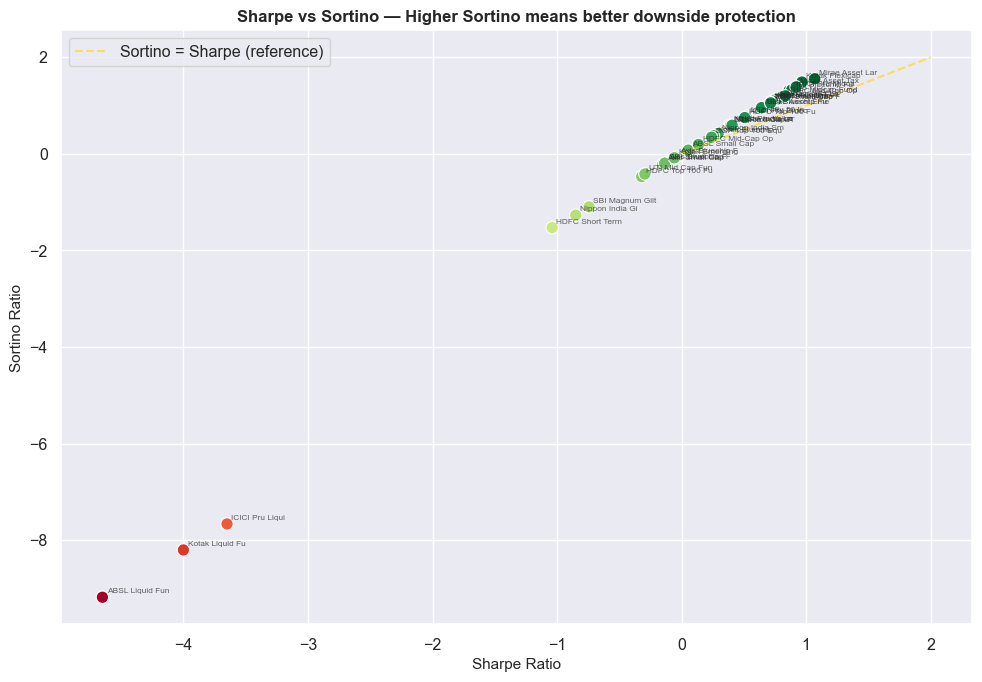

In [5]:
def sortino(ret_series):
    r = ret_series.dropna()
    excess   = r - RF_DAILY
    downside = r[r < RF_DAILY] - RF_DAILY
    if len(downside) < 2 or downside.std() == 0: return np.nan
    return (excess.mean() / downside.std()) * np.sqrt(252)

sortino_scores = {c: sortino(returns[c]) for c in returns.columns}
sortino_df = (pd.Series(sortino_scores, name="sortino_ratio")
              .reset_index().rename(columns={"index":"amfi_code"})
              .merge(fund[["amfi_code","scheme_name","plan"]], on="amfi_code", how="left")
              .sort_values("sortino_ratio", ascending=False).reset_index(drop=True))
sortino_df.index += 1

# Compare Sharpe vs Sortino
compare = (pd.DataFrame(sharpe_scores, index=["sharpe"]).T
           .join(pd.DataFrame(sortino_scores, index=["sortino"]).T))
compare.index.name = "amfi_code"
compare = compare.reset_index().merge(fund[["amfi_code","scheme_name"]], on="amfi_code")

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(compare["sharpe"], compare["sortino"], s=80,
           c=compare["sharpe"], cmap="RdYlGn", edgecolors="white", linewidth=0.8)
ax.plot([0, 2], [0, 2], "gold", linestyle="--", alpha=0.6, label="Sortino = Sharpe (reference)")
ax.set_xlabel("Sharpe Ratio", fontsize=11)
ax.set_ylabel("Sortino Ratio", fontsize=11)
ax.set_title("Sharpe vs Sortino — Higher Sortino means better downside protection", fontsize=12, fontweight="bold")
ax.legend()
for _, row in compare.iterrows():
    ax.annotate(str(row["scheme_name"])[:15], (row["sharpe"], row["sortino"]),
                fontsize=6, alpha=0.7, xytext=(3, 3), textcoords="offset points")
plt.tight_layout(); plt.show()


## 6. Alpha & Beta <a id='6-alpha-beta'></a>
OLS regression: `Fund_Return = α + β × Nifty100_Return`

- **Beta**: sensitivity to market. β > 1 = amplifies market moves.
- **Alpha**: daily intercept × 252 = annualised excess return beyond what beta explains.


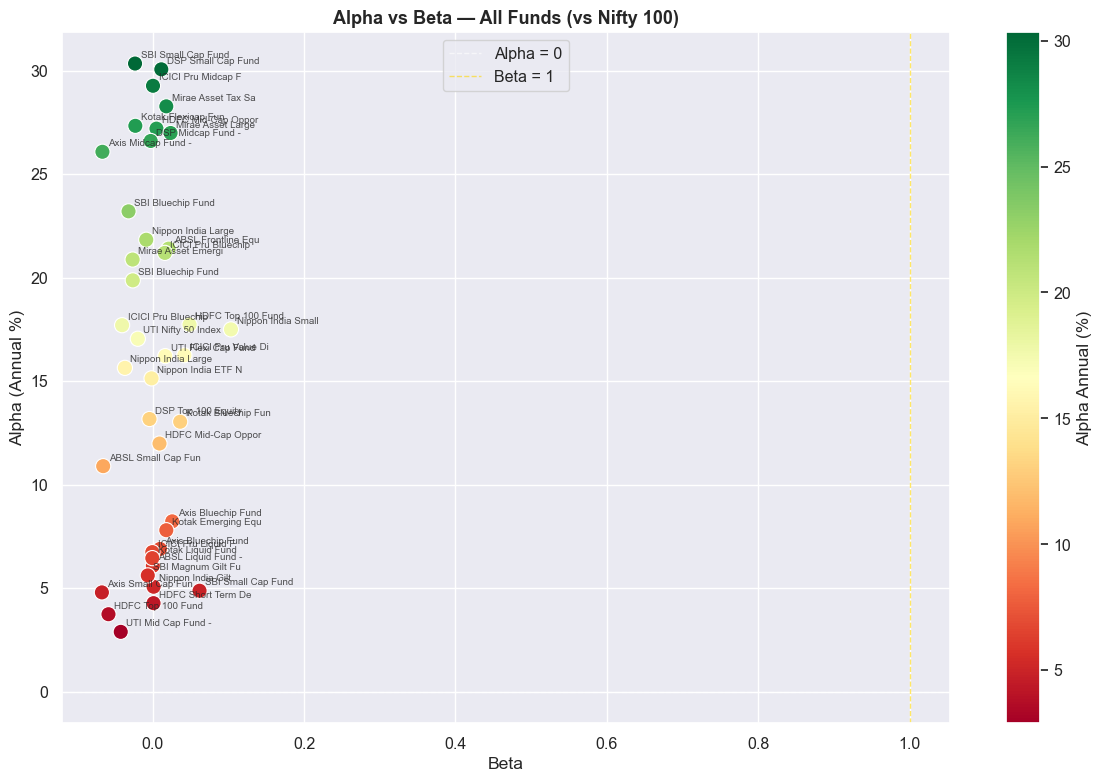


Top 10 by Alpha:
                                       scheme_name    plan  alpha_annual    beta  r_squared
        SBI Small Cap Fund - Regular Plan - Growth Regular       30.3370 -0.0232     0.0001
             DSP Small Cap Fund - Regular - Growth Regular       30.0579  0.0115     0.0000
          ICICI Pru Midcap Fund - Regular - Growth Regular       29.2636  0.0005     0.0000
     Mirae Asset Tax Saver Fund - Regular - Growth Regular       28.2704  0.0181     0.0002
            Kotak Flexicap Fund - Regular - Growth Regular       27.3305 -0.0228     0.0003
HDFC Mid-Cap Opportunities Fund - Regular - Growth Regular       27.1954  0.0051     0.0000
     Mirae Asset Large Cap Fund - Regular - Growth Regular       26.9838  0.0237     0.0005
                DSP Midcap Fund - Regular - Growth Regular       26.5986 -0.0025     0.0000
               Axis Midcap Fund - Regular - Growth Regular       26.0767 -0.0663     0.0019
         SBI Bluechip Fund - Regular Plan - Growth Regular    

In [6]:
bench_ret = nifty100.pct_change().dropna()

ab_rows = []
for code_id in returns.columns:
    fund_ret = returns[code_id].dropna()
    common   = fund_ret.index.intersection(bench_ret.index)
    if len(common) < 60:
        ab_rows.append({"amfi_code": code_id, "alpha_annual": np.nan,
                        "beta": np.nan, "r_squared": np.nan})
        continue
    y = fund_ret.loc[common].values
    x = bench_ret.loc[common].values
    slope, intercept, r_value, p_value, _ = stats.linregress(x, y)
    ab_rows.append({"amfi_code": code_id,
                    "alpha_annual"   : round(intercept * 252 * 100, 4),
                    "beta"           : round(slope, 4),
                    "r_squared"      : round(r_value**2, 4),
                    "p_value"        : round(p_value, 4)})

ab_df = (pd.DataFrame(ab_rows)
         .merge(fund[["amfi_code","scheme_name","plan","sub_category"]], on="amfi_code", how="left"))

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
sc = ax.scatter(ab_df["beta"], ab_df["alpha_annual"],
                c=ab_df["alpha_annual"], cmap="RdYlGn",
                s=120, edgecolors="white", linewidth=0.8, zorder=3)
plt.colorbar(sc, ax=ax, label="Alpha Annual (%)")
ax.axhline(0, color="white", linestyle="--", linewidth=1, alpha=0.6, label="Alpha = 0")
ax.axvline(1, color="gold",  linestyle="--", linewidth=1, alpha=0.6, label="Beta = 1")
for _, row in ab_df.dropna().iterrows():
    ax.annotate(str(row["scheme_name"])[:18], (row["beta"], row["alpha_annual"]),
                fontsize=7, alpha=0.8, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("Beta"); ax.set_ylabel("Alpha (Annual %)")
ax.set_title("Alpha vs Beta — All Funds (vs Nifty 100)", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout(); plt.show()

print("\nTop 10 by Alpha:")
print(ab_df[["scheme_name","plan","alpha_annual","beta","r_squared"]]
      .sort_values("alpha_annual", ascending=False).head(10).to_string(index=False))


## 7. Maximum Drawdown <a id='7-drawdown'></a>
`MDD = min(NAV / running_max - 1)`

The worst peak-to-trough decline experienced. Peak date and trough date identify the exact drawdown window.


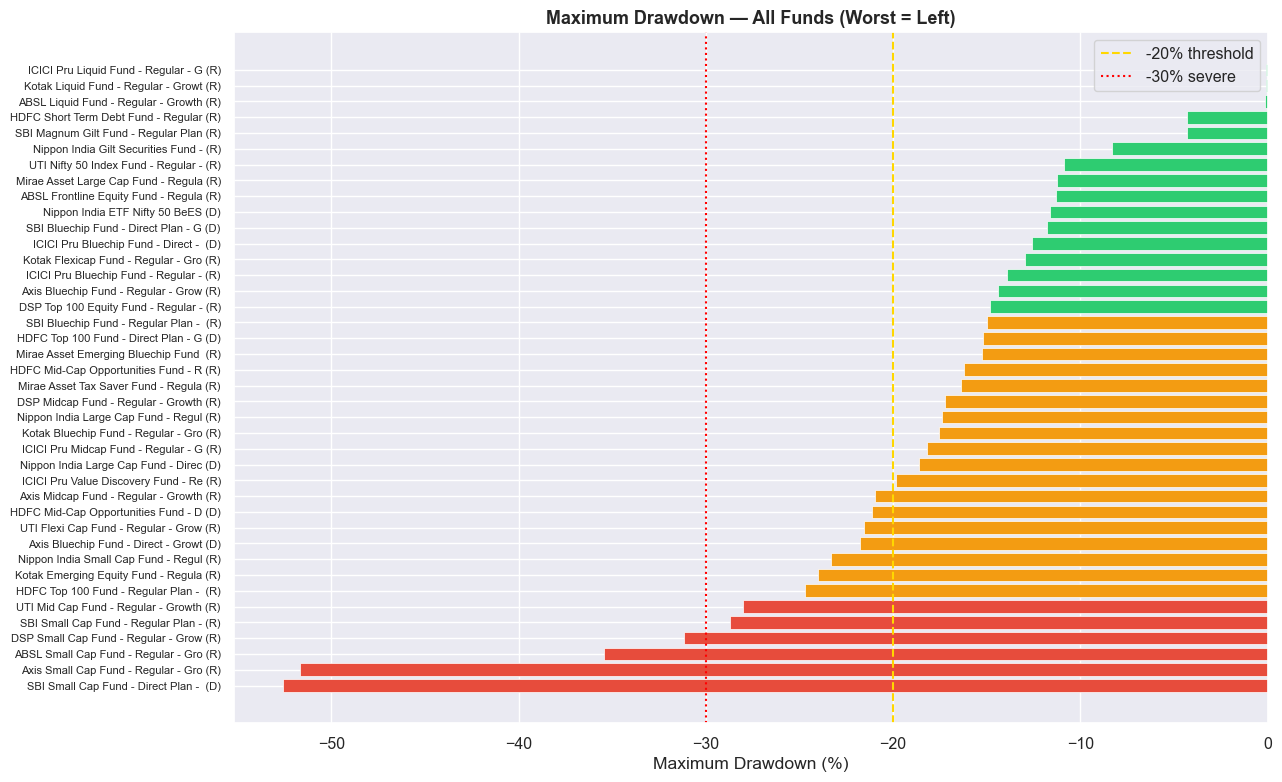

In [7]:
def max_drawdown(nav_series):
    s = nav_series.dropna()
    if len(s) < 2: return np.nan, None, None
    running_max = s.cummax()
    drawdown    = s / running_max - 1
    mdd_val     = drawdown.min()
    mdd_date    = drawdown.idxmin()
    peak_date   = s.loc[:mdd_date].idxmax()
    return mdd_val, peak_date, mdd_date

mdd_rows = []
for code_id in nav_wide.columns:
    mdd_val, peak_dt, trough_dt = max_drawdown(nav_wide[code_id])
    mdd_rows.append({"amfi_code": code_id,
                     "max_drawdown_pct": round(mdd_val*100, 2) if not np.isnan(mdd_val) else np.nan,
                     "peak_date"  : str(peak_dt.date())   if peak_dt   else None,
                     "trough_date": str(trough_dt.date()) if trough_dt else None,
                     "days_to_trough": (trough_dt-peak_dt).days if (peak_dt and trough_dt) else None})

mdd_df = (pd.DataFrame(mdd_rows)
          .merge(fund[["amfi_code","scheme_name","plan","sub_category"]], on="amfi_code", how="left")
          .sort_values("max_drawdown_pct"))

# Waterfall-style bar
fig, ax = plt.subplots(figsize=(13, 8))
bar_colors = ["#e74c3c" if v < -25 else "#f39c12" if v < -15 else "#2ecc71"
              for v in mdd_df["max_drawdown_pct"]]
ax.barh(range(len(mdd_df)), mdd_df["max_drawdown_pct"].values,
        color=bar_colors, edgecolor="white", linewidth=0.5)
ax.set_yticks(range(len(mdd_df)))
ax.set_yticklabels([f"{r['scheme_name'][:35]} ({r['plan'][0]})"
                    for _, r in mdd_df.iterrows()], fontsize=8)
ax.axvline(-20, color="gold", linestyle="--", linewidth=1.5, label="-20% threshold")
ax.axvline(-30, color="red",  linestyle=":", linewidth=1.5, label="-30% severe")
ax.set_xlabel("Maximum Drawdown (%)")
ax.set_title("Maximum Drawdown — All Funds (Worst = Left)", fontsize=13, fontweight="bold")
ax.legend(); plt.tight_layout(); plt.show()


## 8. Fund Scorecard (0–100) <a id='8-scorecard'></a>

**Composite Score:**
| Metric | Weight |
|--------|--------|
| 3-Year CAGR rank | 30% |
| Sharpe Ratio rank | 25% |
| Alpha rank | 20% |
| Expense Ratio rank (inverse) | 15% |
| Max Drawdown rank (inverse) | 10% |


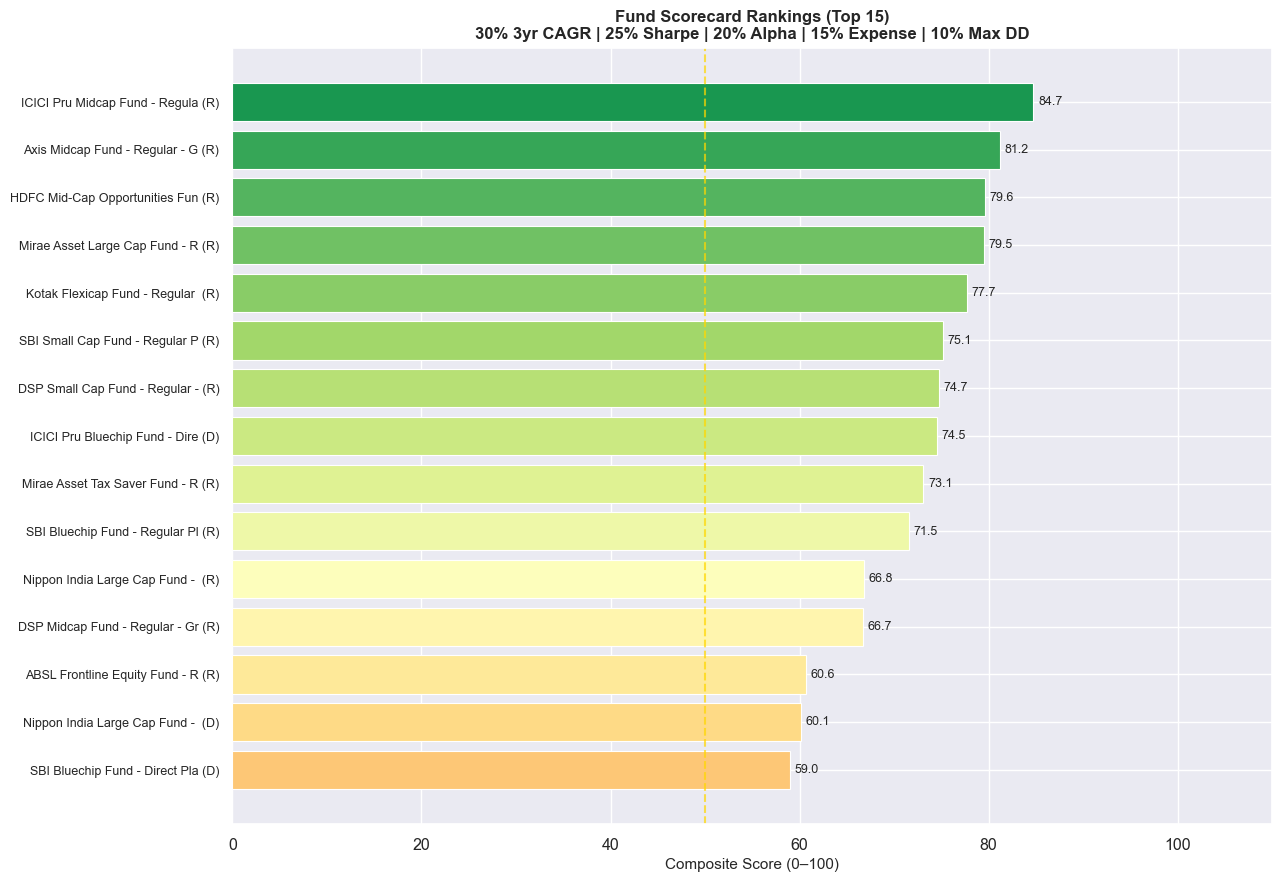

Full Scorecard:
 rank                                           scheme_name    plan  scorecard  cagr_3yr_pct  sharpe_ratio  alpha_annual  expense_ratio_pct  max_drawdown_pct
    1              ICICI Pru Midcap Fund - Regular - Growth Regular      84.74         31.78      0.883256       29.2636               1.36            -18.19
    2                   Axis Midcap Fund - Regular - Growth Regular      81.16         35.11      0.730547       26.0767               1.38            -20.96
    3    HDFC Mid-Cap Opportunities Fund - Regular - Growth Regular      79.62         32.44      0.808268       27.1954               1.38            -16.22
    4         Mirae Asset Large Cap Fund - Regular - Growth Regular      79.49         34.00      1.068224       26.9838               1.46            -11.27
    5                Kotak Flexicap Fund - Regular - Growth Regular      77.69         29.58      0.965561       27.3305               1.45            -12.97
    6            SBI Small Cap Fund 

In [8]:
scorecard = pd.read_csv(PROC / "fund_scorecard.csv")

fig, ax = plt.subplots(figsize=(13, 9))
top15    = scorecard.head(15).copy()
top15["label"] = top15["scheme_name"].str[:30] + " (" + top15["plan"].str[0] + ")"
bar_colors_s   = plt.cm.RdYlGn(np.linspace(0.35, 0.9, len(top15)))[::-1]
bars = ax.barh(range(len(top15)), top15["scorecard"].values,
               color=bar_colors_s, edgecolor="white", linewidth=0.8)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15["label"].values, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Composite Score (0–100)", fontsize=11)
ax.set_title("Fund Scorecard Rankings (Top 15)\n"
             "30% 3yr CAGR | 25% Sharpe | 20% Alpha | 15% Expense | 10% Max DD",
             fontsize=12, fontweight="bold")
ax.axvline(50, color="gold", linestyle="--", alpha=0.7)
for bar_p, val in zip(bars, top15["scorecard"]):
    ax.text(bar_p.get_width() + 0.5, bar_p.get_y() + bar_p.get_height()/2,
            f"{val:.1f}", va="center", fontsize=9)
ax.set_xlim(0, 110)
plt.tight_layout(); plt.show()

print("Full Scorecard:")
print(scorecard[["rank","scheme_name","plan","scorecard","cagr_3yr_pct",
                  "sharpe_ratio","alpha_annual","expense_ratio_pct","max_drawdown_pct"]]
      .head(20).to_string(index=False))


## 9. Benchmark Comparison <a id='9-benchmark'></a>
Top 5 scorecard funds rebased to 100, plotted against Nifty 50 and Nifty 100.  
Tracking Error = `std(fund_return - benchmark_return) × √252`


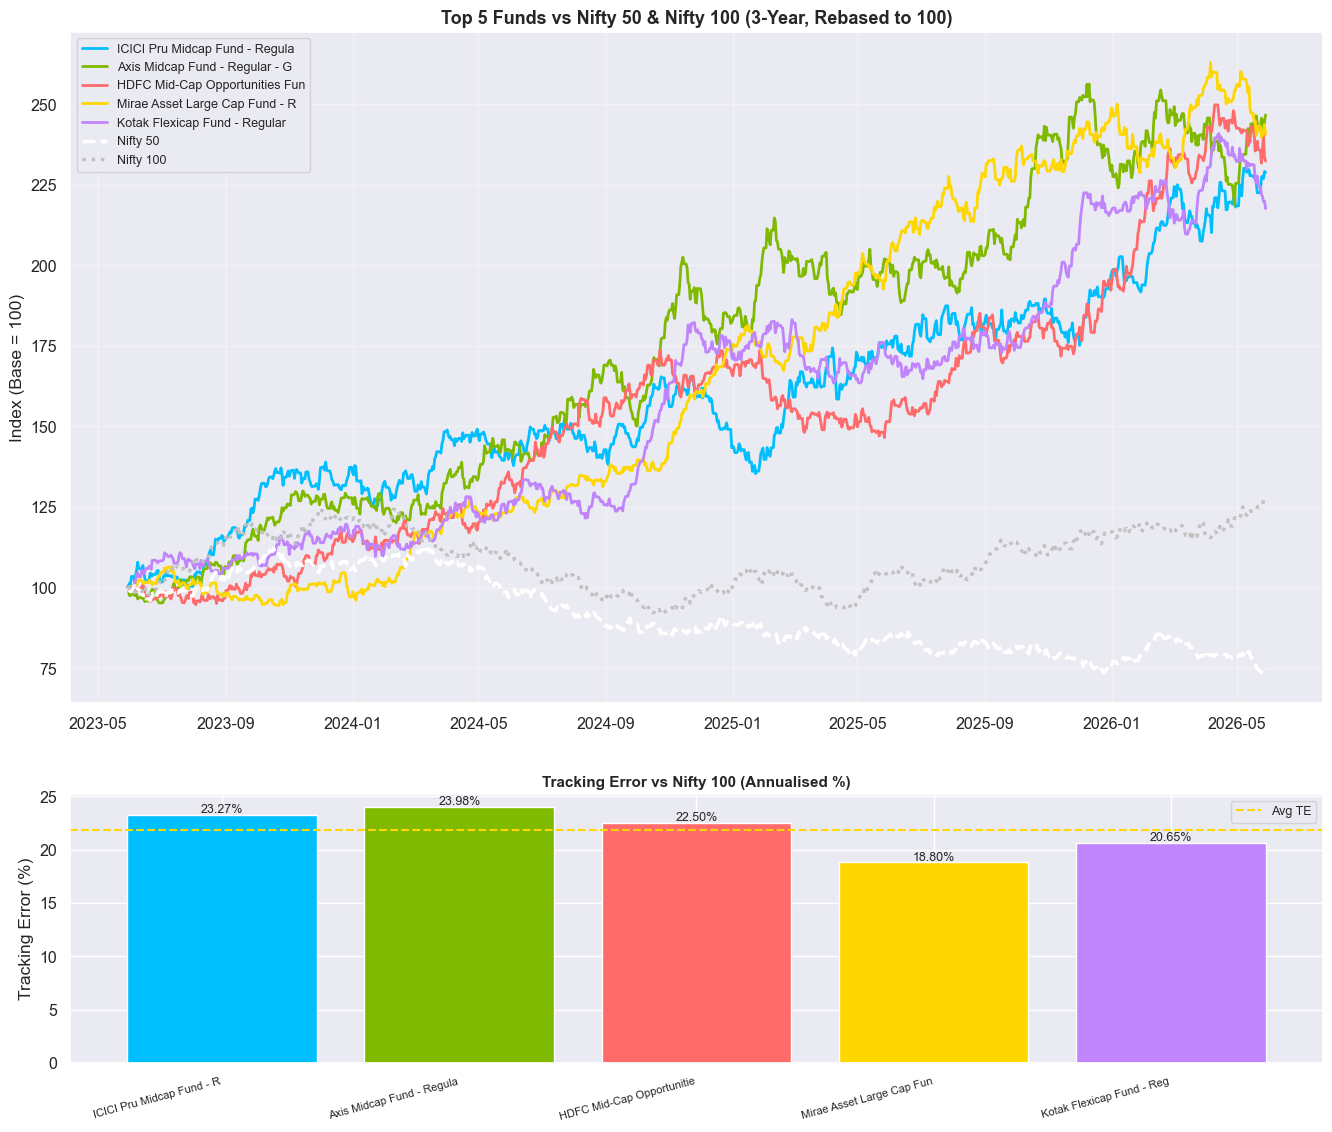

Tracking Error computed vs Nifty 100.


In [9]:
scorecard = pd.read_csv(PROC / "fund_scorecard.csv")
top5_codes = scorecard.head(5)["amfi_code"].tolist()
top5_names = scorecard.head(5)["scheme_name"].str[:30].tolist()

start_3yr = nav_wide.index.max() - pd.DateOffset(years=3)
nav_3yr   = nav_wide.loc[start_3yr:, top5_codes].dropna(how="all")
n50_3yr   = nifty50.loc[start_3yr:].dropna()
n100_3yr  = nifty100.loc[start_3yr:].dropna()

def rebase(s): return s / s.dropna().iloc[0] * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 12),
                          gridspec_kw={"height_ratios": [3, 1.2]})
colors_p = ["#00BFFF","#7FBA00","#FF6B6B","#FFD700","#C084FC"]

for i, (code_id, name) in enumerate(zip(top5_codes, top5_names)):
    s = rebase(nav_3yr[code_id].dropna())
    axes[0].plot(s.index, s.values, color=colors_p[i], linewidth=2, label=name)

axes[0].plot(rebase(n50_3yr).index,  rebase(n50_3yr).values,
             color="white", linewidth=2.5, linestyle="--", label="Nifty 50")
axes[0].plot(rebase(n100_3yr).index, rebase(n100_3yr).values,
             color="silver", linewidth=2.5, linestyle=":",  label="Nifty 100")
axes[0].set_title("Top 5 Funds vs Nifty 50 & Nifty 100 (3-Year, Rebased to 100)",
                   fontsize=13, fontweight="bold")
axes[0].set_ylabel("Index (Base = 100)")
axes[0].legend(fontsize=9, loc="upper left")
axes[0].grid(True, alpha=0.3)

bench_ret_3yr = n100_3yr.pct_change().dropna()
te_vals, te_names = [], []
for code_id, name in zip(top5_codes, top5_names):
    fr = nav_3yr[code_id].pct_change().dropna()
    common = fr.index.intersection(bench_ret_3yr.index)
    if len(common) < 30: continue
    te = (fr.loc[common] - bench_ret_3yr.loc[common]).std() * np.sqrt(252) * 100
    te_vals.append(round(te, 2)); te_names.append(name[:25])

axes[1].bar(te_names, te_vals, color=colors_p[:len(te_vals)], edgecolor="white")
axes[1].axhline(np.mean(te_vals), color="gold", linestyle="--", label="Avg TE")
axes[1].set_title("Tracking Error vs Nifty 100 (Annualised %)", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Tracking Error (%)")
axes[1].set_xticklabels(te_names, rotation=15, ha="right", fontsize=8)
axes[1].legend(fontsize=9)
for i, (val, name) in enumerate(zip(te_vals, te_names)):
    axes[1].text(i, val + 0.2, f"{val:.2f}%", ha="center", fontsize=9)
plt.tight_layout(pad=2.5); plt.show()
print("Tracking Error computed vs Nifty 100.")


---
## Summary of Key Metrics

| Metric | Formula | Risk-Free Rate |
|--------|---------|----------------|
| Daily Return | NAV_t / NAV_t-1 - 1 | — |
| CAGR | (NAV_end / NAV_start)^(1/n) - 1 | — |
| Sharpe | (Rp - Rf) / Std × √252 | 6.5% |
| Sortino | (Rp - Rf) / Downside_Std × √252 | 6.5% |
| Alpha | OLS intercept × 252 (annualised) | — |
| Beta | OLS slope vs Nifty 100 | — |
| Max Drawdown | min(NAV / running_max - 1) | — |
| Scorecard | 30% CAGR + 25% Sharpe + 20% Alpha + 15% ER + 10% MDD | — |

**Exported CSVs:**
- `data/processed/daily_returns.csv`
- `data/processed/cagr_table.csv`
- `data/processed/alpha_beta.csv`
- `data/processed/fund_scorecard.csv`

**Exported Charts:**
- `reports/charts/16_benchmark_comparison.png`
- `reports/charts/17_fund_scorecard.png`
- `reports/charts/18_alpha_beta_scatter.png`
